In [1]:
# setup + imports

import sys
import os

# allowing notebook to access utils.py from parent folder
sys.path.append(os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt

from utils import load_ct_series

# reload utils in case of updates
import importlib
import utils
importlib.reload(utils)

<module 'utils' from '/Users/shivalibajaj/git-portfolio/AirAware - Lung Health Intelligence System/utils.py'>

In [2]:
# CT Loader (Foundation)
ct_volume = load_ct_series("./sample.dcm")

print("Volume shape:", ct_volume.shape)

# quick validation → confirms we are looking at lung region
print("Mean HU:", np.mean(ct_volume))

Volume shape: (512, 512)
Mean HU: -870.2389602661133


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

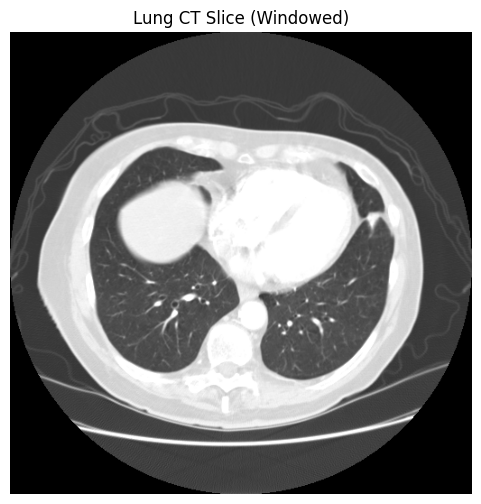

In [3]:
# CT Visualization Cell (what raw CT actually looks like after windowing)

def ct_window(image, level=-600, width=1500):
    min_val = level - width // 2
    max_val = level + width // 2
    
    image = np.clip(image, min_val, max_val)
    return (image - min_val) / (max_val - min_val)

view = ct_window(ct_volume)

plt.figure(figsize=(6,6))
plt.imshow(view, cmap="gray")
plt.title("Lung CT Slice (Windowed)")
plt.axis("off")

In [4]:
# Lung Segmentation Cell (fixed thresholds for our CT)

from scipy.ndimage import binary_opening, binary_closing, binary_fill_holes, label

# step 1: broader body mask (doesn't kill lungs)
body_mask = ct_volume > -1000   # includes lungs also

# step 2: lung region (air-like)
lung_mask = (ct_volume < -400) & (ct_volume > -1000)

# step 3: clean noise
lung_mask = binary_opening(lung_mask, structure=np.ones((3, 3)))
lung_mask = binary_closing(lung_mask, structure=np.ones((5, 5)))

# step 4: fills holes
lung_mask = binary_fill_holes(lung_mask)

# step 5: identify major connected regions (candidate anatomical structures)
labeled_mask, num_regions = label(lung_mask)

region_sizes = [(labeled_mask == i).sum() for i in range(1, num_regions + 1)]

# selecting top regions to capture both lungs and avoid missing partial structures
top_regions = np.argsort(region_sizes)[-4:] + 1

candidate_mask = np.isin(labeled_mask, top_regions)

# step 6: apply anatomical constraint (lungs reside in upper thoracic region)
height = candidate_mask.shape[0]

# step 6: refine by removing edge noise (focus on central thoracic region)
height, width = candidate_mask.shape

refined_mask = np.zeros_like(candidate_mask)

# keeping central 70% vertically (lungs lie roughly here)
top = int(0.15 * height)
bottom = int(0.85 * height)

refined_mask[top:bottom, :] = 1

# final lung mask
clean_lung_mask = candidate_mask & refined_mask

# applies mask
segmented_lung = ct_volume * clean_lung_mask

print("Segmentation complete")

Segmentation complete


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

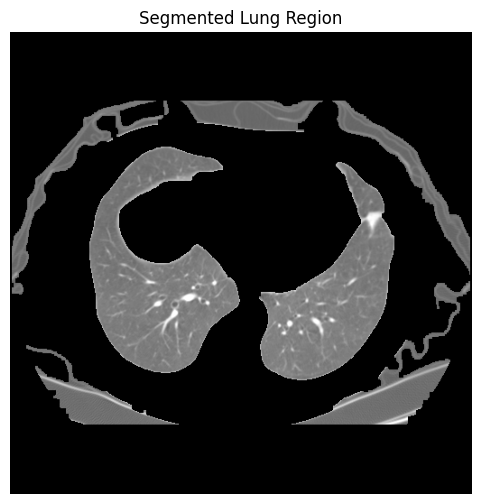

In [5]:
# Segmented Lung Visualization Cell (final tuned version)

# applying lung window first so contrast is meaningful
windowed_ct = ct_window(ct_volume)

# masking + slight contrast boost (warna image dull lagti hai)
lung_only = (windowed_ct * clean_lung_mask) ** 0.6

plt.figure(figsize=(6,6))
plt.imshow(lung_only, cmap="gray")
plt.title("Segmented Lung Region")
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

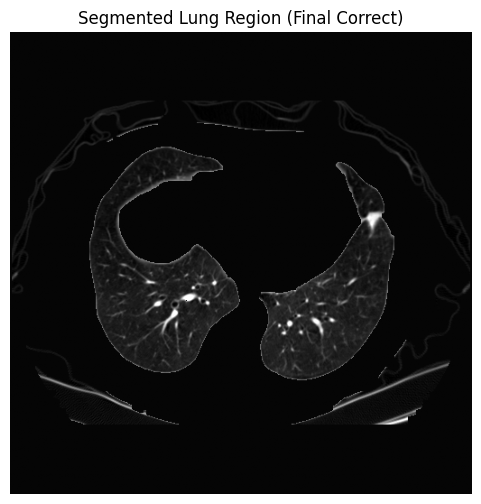

In [6]:
# Segmented Lung Visualization Cell (correct contrast, no inversion)

# copy so original data is untouched
display_lung = segmented_lung.copy()

# hide background completely
display_lung[display_lung == 0] = -1000  # push background to pure black

# apply lung window (same as before, but now works correctly)
segmented_view = ct_window(display_lung)

plt.figure(figsize=(6, 6))
plt.imshow(segmented_view, cmap="gray")
plt.title("Segmented Lung Region (Final Correct)")
plt.axis("off")

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

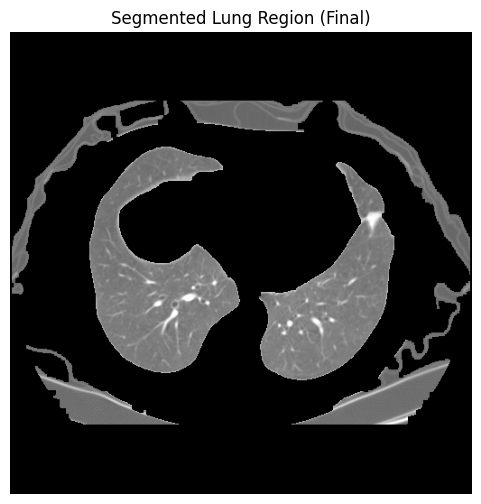

In [7]:
# Segmented Lung Visualization Cell (final professional version)

# step 1: apply lung window on full CT (correct contrast)
windowed_ct = ct_window(ct_volume)

# step 2: apply segmentation mask
lung_only = (windowed_ct * clean_lung_mask) ** 0.6

plt.figure(figsize=(6, 6))
plt.imshow(lung_only, cmap="gray")
plt.title("Segmented Lung Region (Final)")
plt.axis("off")

Total pixels: 262144
Non-zero pixels (lung area): 62831


(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

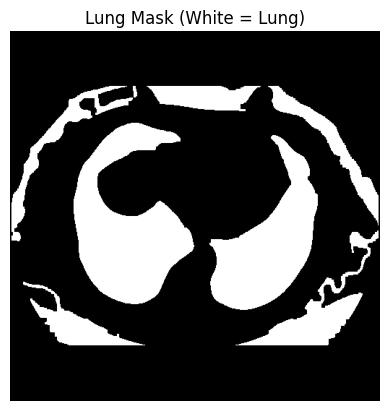

In [8]:
# Debug Cell (understand what segmentation produced)

print("Total pixels:", segmented_lung.size)
print("Non-zero pixels (lung area):", np.count_nonzero(segmented_lung))

# show mask directly (TRUE/FALSE image)
plt.imshow(clean_lung_mask, cmap="gray")
plt.title("Lung Mask (White = Lung)")
plt.axis("off")